# Nutritional Intake — PCA and Clustering Analysis

This notebook reduces the dimensionality of longitudinal nutritional 
intake data using PCA and identifies distinct dietary profiles 
among participants using K-Means clustering.

## Data
- Source: Dietary records collected via food diaries across the study
- Participants: 92 overweight and obese adults with complete nutritional data 
- Variables: macronutrients, micronutrients, food group intakes

## Method
- Variables with >5% missing values excluded
- Remaining missing values imputed with column mean
- StandardScaler normalization
- PCA for visualization (2 components)
- K-Means clustering (k=3) on full standardized feature matrix
- Silhouette score for cluster quality evaluation

## Key Finding
Three distinct nutritional profiles were identified, though cluster 
separation was limited (silhouette score = 0.39), consistent with 
the known difficulty of clustering dietary data in free-living conditions.

Original shape: (184, 192)
Nutritional variables: 189
Participants: 92
Variables after missing filter: 189
Remaining missing values: 0

PC1: 26.21%
PC2: 10.31%
Total variance explained: 36.52%


C:\Users\Attioui Hicham\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Silhouette score (k=3): 0.061

Cluster sizes:
0    33
1    21
2    38


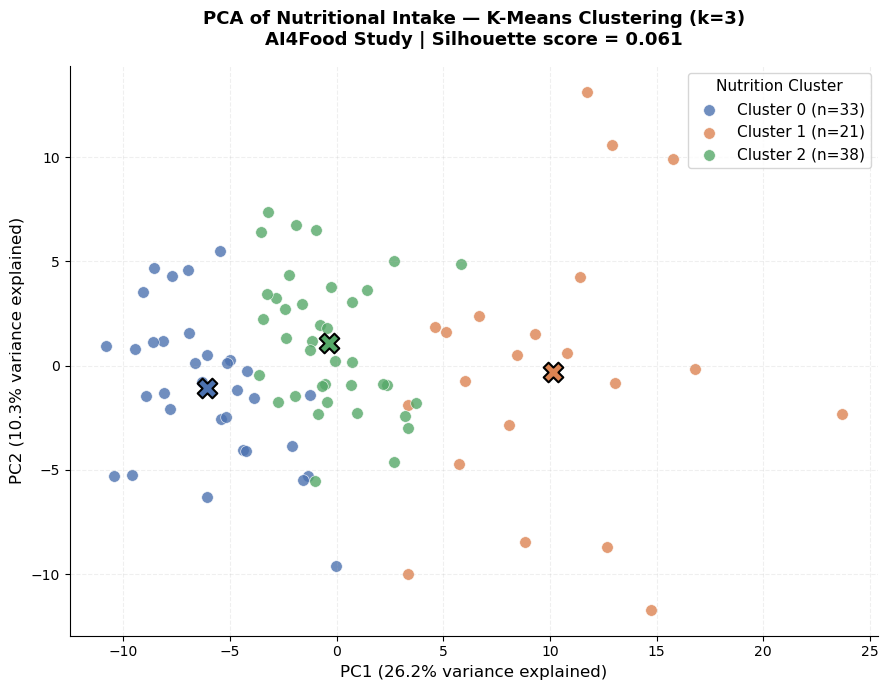

Figure saved: figures/nutrition_pca_clusters.png


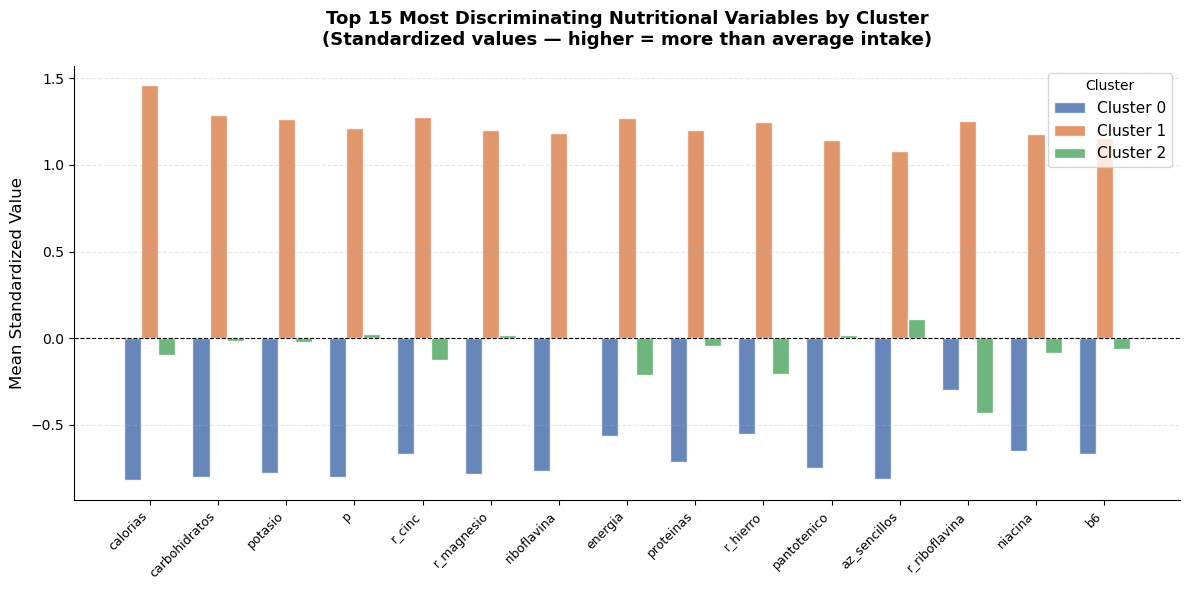

Figure saved: figures/nutrition_cluster_profiles.png

Results saved.
Participants: 92 | Clusters: 3 | Variables used: 189


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

os.makedirs("figures", exist_ok=True)
os.makedirs("data/results", exist_ok=True)

# CONFIGURATION

FILE_PATH       = "data/dieta.tsv"
ID_COL          = "id_voluntario"
EXCLUDE_COLS    = ["id_voluntario", "id_cuestionario"]
MAX_MISSING_PCT = 5      # exclude variables with >5% missing
N_COMPONENTS    = 2      # PCA components
N_CLUSTERS      = 3      # K-Means clusters
COLORS          = ["#4C72B0", "#DD8452", "#55A868"]

# LOAD DATA

df = pd.read_csv(FILE_PATH, sep="\t")
print(f"Original shape: {df.shape}")

# SELECT NUTRITIONAL VARIABLES

numeric_cols   = df.select_dtypes(include=np.number).columns
nutrition_cols = [c for c in numeric_cols if c not in EXCLUDE_COLS]
print(f"Nutritional variables: {len(nutrition_cols)}")

# AVERAGE PER PARTICIPANT

participant_data = (
    df[[ID_COL] + nutrition_cols]
    .groupby(ID_COL)
    .mean()
    .reset_index()
)
print(f"Participants: {participant_data.shape[0]}")

# FILTER AND IMPUTE

X = participant_data[nutrition_cols].copy()

missing_pct = X.isnull().mean() * 100
keep_cols   = missing_pct[missing_pct <= MAX_MISSING_PCT].index
X           = X[keep_cols]
print(f"Variables after missing filter: {X.shape[1]}")

X = X.fillna(X.mean())
print(f"Remaining missing values: {X.isnull().sum().sum()}")

# STANDARDIZE

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA

pca   = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)
ev    = pca.explained_variance_ratio_ * 100

print(f"\nPC1: {ev[0]:.2f}%")
print(f"PC2: {ev[1]:.2f}%")
print(f"Total variance explained: {ev.sum():.2f}%")

# CLUSTERING (on full standardized data)

kmeans   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, clusters)
print(f"\nSilhouette score (k={N_CLUSTERS}): {score:.3f}")

sizes = pd.Series(clusters).value_counts().sort_index()
print(f"\nCluster sizes:\n{sizes.to_string()}")

# PCA RESULTS TABLE

pca_df = pd.DataFrame({
    "id_voluntario": participant_data[ID_COL],
    "PC1":           X_pca[:, 0],
    "PC2":           X_pca[:, 1],
    "Cluster":       clusters
})

# FIGURE 1 : PCA SCATTER PLOT

fig, ax = plt.subplots(figsize=(9, 7))

for i, cluster in enumerate(sorted(pca_df["Cluster"].unique())):
    subset = pca_df[pca_df["Cluster"] == cluster]
    ax.scatter(
        subset["PC1"], subset["PC2"],
        s=70, alpha=0.8,
        color=COLORS[i % len(COLORS)],
        label=f"Cluster {cluster} (n={len(subset)})",
        edgecolors='white', linewidths=0.5
    )

centroids_pca = []
for cluster in sorted(pca_df["Cluster"].unique()):
    mask = pca_df["Cluster"] == cluster
    centroids_pca.append([
        pca_df.loc[mask, "PC1"].mean(),
        pca_df.loc[mask, "PC2"].mean()
    ])

for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, s=200, marker='X',
               color=COLORS[i % len(COLORS)],
               edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel(f"PC1 ({ev[0]:.1f}% variance explained)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev[1]:.1f}% variance explained)", fontsize=12)
ax.set_title(
    f"PCA of Nutritional Intake — K-Means Clustering (k={N_CLUSTERS})\n"
    f"AI4Food Study | Silhouette score = {score:.3f}",
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(title="Nutrition Cluster", fontsize=11, title_fontsize=11)
ax.grid(alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/nutrition_pca_clusters.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/nutrition_pca_clusters.png")

# FIGURE 2 : CLUSTER NUTRITIONAL PROFILES (TOP 15 VARIABLES)

scaled_df             = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df["Cluster"]  = clusters
cluster_profiles      = scaled_df.groupby("Cluster").mean()

cluster_std = cluster_profiles.std(axis=0)
top_vars    = cluster_std.nlargest(15).index
top_profiles = cluster_profiles[top_vars]

fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(top_vars))
width = 0.25

for i, cluster in enumerate(sorted(cluster_profiles.index)):
    ax.bar(
        x + i * width,
        top_profiles.loc[cluster],
        width=width,
        color=COLORS[i % len(COLORS)],
        label=f"Cluster {cluster}",
        alpha=0.85,
        edgecolor='white'
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width)
ax.set_xticklabels(top_vars, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Mean Standardized Value", fontsize=12)
ax.set_title(
    f"Top 15 Most Discriminating Nutritional Variables by Cluster\n"
    f"(Standardized values — higher = more than average intake)",
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(title="Cluster", fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/nutrition_cluster_profiles.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/nutrition_cluster_profiles.png")

# SAVE RESULTS

pca_df.to_csv("data/results/nutrition_pca_clusters.csv", index=False)
cluster_profiles.to_csv("data/results/nutrition_cluster_profiles.csv")

print(f"\nResults saved.")
print(f"Participants: {len(pca_df)} | Clusters: {N_CLUSTERS} | Variables used: {X.shape[1]}")